<a href="https://colab.research.google.com/github/vedantpathak2020-hue/EfficientNet_Pytorch_Model/blob/main/EfficientNetModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
zimport torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import numpy as np
import time
from functools import partial
from torch.nn.quantized import FloatFunctional
import torch.ao.quantization as quant

# Setup Device: Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. DATA PIPELINE --- #
# 1. Resize 28x28 to 32x32 (32x32 is the absolute mathematical minimum for EfficientNet)
# 2. Duplicate the single grayscale channel into 3 identical channels (fake RGB)
# 3. Convert to Tensor and Normalize
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Downloading and preparing data...")
# Load the full training dataset #
full_train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 80-20 Split for Train and Validation #
train_size = int(0.8 * len(full_train_set))
val_size = len(full_train_set) - train_size
train_set, val_set = torch.utils.data.random_split(full_train_set, [train_size, val_size])

# Load the test dataset (which we will keep completely hidden until the end) #
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders for all three sets #
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)


# --- 2. ARCHITECTURE FROM SCRATCH (C-Blueprint) --- #

class ConvBNAct(nn.Module):
    def __init__(self, in_c, out_c, kernel_size, stride, groups=1):
        super().__init__()
        padding = kernel_size // 2
        # groups=in_c makes it a "Depthwise" convolution #
        self.conv = nn.Conv2d(in_c, out_c, kernel_size, stride, padding, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(out_c)
        self.act = nn.SiLU()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class SqueezeExcitation(nn.Module):
    def __init__(self, in_c, reduced_c):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_c, reduced_c, 1),
            nn.SiLU(),
            nn.Conv2d(reduced_c, in_c, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.se(x)

class MBConv(nn.Module):
    def __init__(self, in_c, out_c, kernel_size, stride, expand_ratio):
        super().__init__()
        self.use_residual = (in_c == out_c and stride == 1)
        hidden_c = in_c * expand_ratio

        self.skip_add = FloatFunctional()

        layers = []
        if expand_ratio != 1:
            layers.append(ConvBNAct(in_c, hidden_c, kernel_size=1, stride=1)) # Expand

        layers.extend([
            ConvBNAct(hidden_c, hidden_c, kernel_size, stride, groups=hidden_c), # Depthwise
            SqueezeExcitation(hidden_c, max(1, in_c // 4)),                      # SE Attention
            nn.Conv2d(hidden_c, out_c, 1, bias=False),                           # Pointwise Linear
            nn.BatchNorm2d(out_c)
        ])
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual: return self.skip_add.add(x, self.block(x))
        return self.block(x)

class CustomEfficientNetB0(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.quant = quant.QuantStub()
        self.dequant = quant.DeQuantStub()

        # B0 Configuration: [expand_ratio, channels, repeats, stride, kernel_size] #
        b0_config = [
            [1, 16, 1, 1, 3], [6, 24, 2, 2, 3], [6, 40, 2, 2, 5],
            [6, 80, 3, 2, 3], [6, 112, 3, 1, 5], [6, 192, 4, 2, 5], [6, 320, 1, 1, 3]
        ]

        layers = [ConvBNAct(3, 32, 3, 2)] # Stem Convolution

        in_c = 32
        for expand_ratio, out_c, repeats, stride, kernel_size in b0_config:
            for i in range(repeats):
                s = stride if i == 0 else 1
                layers.append(MBConv(in_c, out_c, kernel_size, s, expand_ratio))
                in_c = out_c

        layers.append(ConvBNAct(in_c, 1280, 1, 1)) # Final Head Convolution

        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.quant(x)          # <--- NEW: Enter INT8
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        x = self.dequant(x)        # <--- NEW: Exit back to Float
        return x


Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.23MB/s]


In [ ]:

# --- 3. INITIALIZATION & TRAINING ---

print("Initializing Custom EfficientNet-B0 from scratch...")
# We initialize our custom class directly. No pretrained weights!

model = CustomEfficientNetB0(num_classes=10).to(device)

# Define how we calculate errors (CrossEntropy) and how we update weights (Adam)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Slightly higher learning rate for from-scratch

# Bumped up to 10 epochs so you can see it actually learn from zero
epochs = 25
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

print("Starting Training...")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()       # Clear old gradients
        outputs = model(inputs)     # Forward pass
        loss = criterion(outputs, labels) # Calculate error
        loss.backward()             # Backward pass
        optimizer.step()            # Update weights

        # Track telemetry
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(100 * correct / total)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accuracies[-1]:.2f}% | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accuracies[-1]:.2f}%")


Initializing Custom EfficientNet-B0 from scratch...
Starting Training...
Epoch 1/25 | Train Loss: 0.2889 | Train Acc: 91.33% | Val Loss: 0.0974 | Val Acc: 97.22%
Epoch 2/25 | Train Loss: 0.0857 | Train Acc: 97.68% | Val Loss: 0.0782 | Val Acc: 98.01%
Epoch 3/25 | Train Loss: 0.0693 | Train Acc: 98.22% | Val Loss: 0.0726 | Val Acc: 98.11%
Epoch 4/25 | Train Loss: 0.0634 | Train Acc: 98.35% | Val Loss: 0.0746 | Val Acc: 98.03%
Epoch 5/25 | Train Loss: 0.0493 | Train Acc: 98.74% | Val Loss: 0.0557 | Val Acc: 98.46%
Epoch 6/25 | Train Loss: 0.0548 | Train Acc: 98.58% | Val Loss: 0.0671 | Val Acc: 98.14%
Epoch 7/25 | Train Loss: 0.0384 | Train Acc: 98.97% | Val Loss: 0.0526 | Val Acc: 98.58%
Epoch 8/25 | Train Loss: 0.0365 | Train Acc: 99.01% | Val Loss: 0.0680 | Val Acc: 97.98%
Epoch 9/25 | Train Loss: 0.0353 | Train Acc: 99.05% | Val Loss: 0.0437 | Val Acc: 98.84%
Epoch 10/25 | Train Loss: 0.0289 | Train Acc: 99.26% | Val Loss: 0.0420 | Val Acc: 98.88%
Epoch 11/25 | Train Loss: 0.0258 | T


🚀 HARDWARE INFERENCE PROFILING (Batch Size = 1)
Simulating a single hardware prediction cycle to track time and VRAM buffers...
Gathering data for final metrics (using Test Set)...

                            FINAL TEST PERFORMANCE                                
Test Loss: 0.0318
Test Accuracy: 99.09%
Mean Inference Time per Image: 0.1649 ms
Hardware Profiling Total Cycle (Batch=1): 59.2863 ms

             DETAILED SEQUENTIAL LAYER-BY-LAYER EXECUTION TIMING PROFILE          
Execution Order / Layer Path                  | Time (ms)  | Mem Before   | Mem After   | Delta VRAM
--------------------------------------------------------------------------------------------------------------
-> features.0 (ConvBNAct)                     | 0.487      | 79.354    MB | 79.385   MB |     +0.031 MB
-> features.1 (MBConv)                        | 2.375      | 79.385    MB | 79.400   MB |     +0.016 MB
-> features.1.block.0 (ConvBNAct)             | 0.392      | 79.385    MB | 79.416   MB |     +0

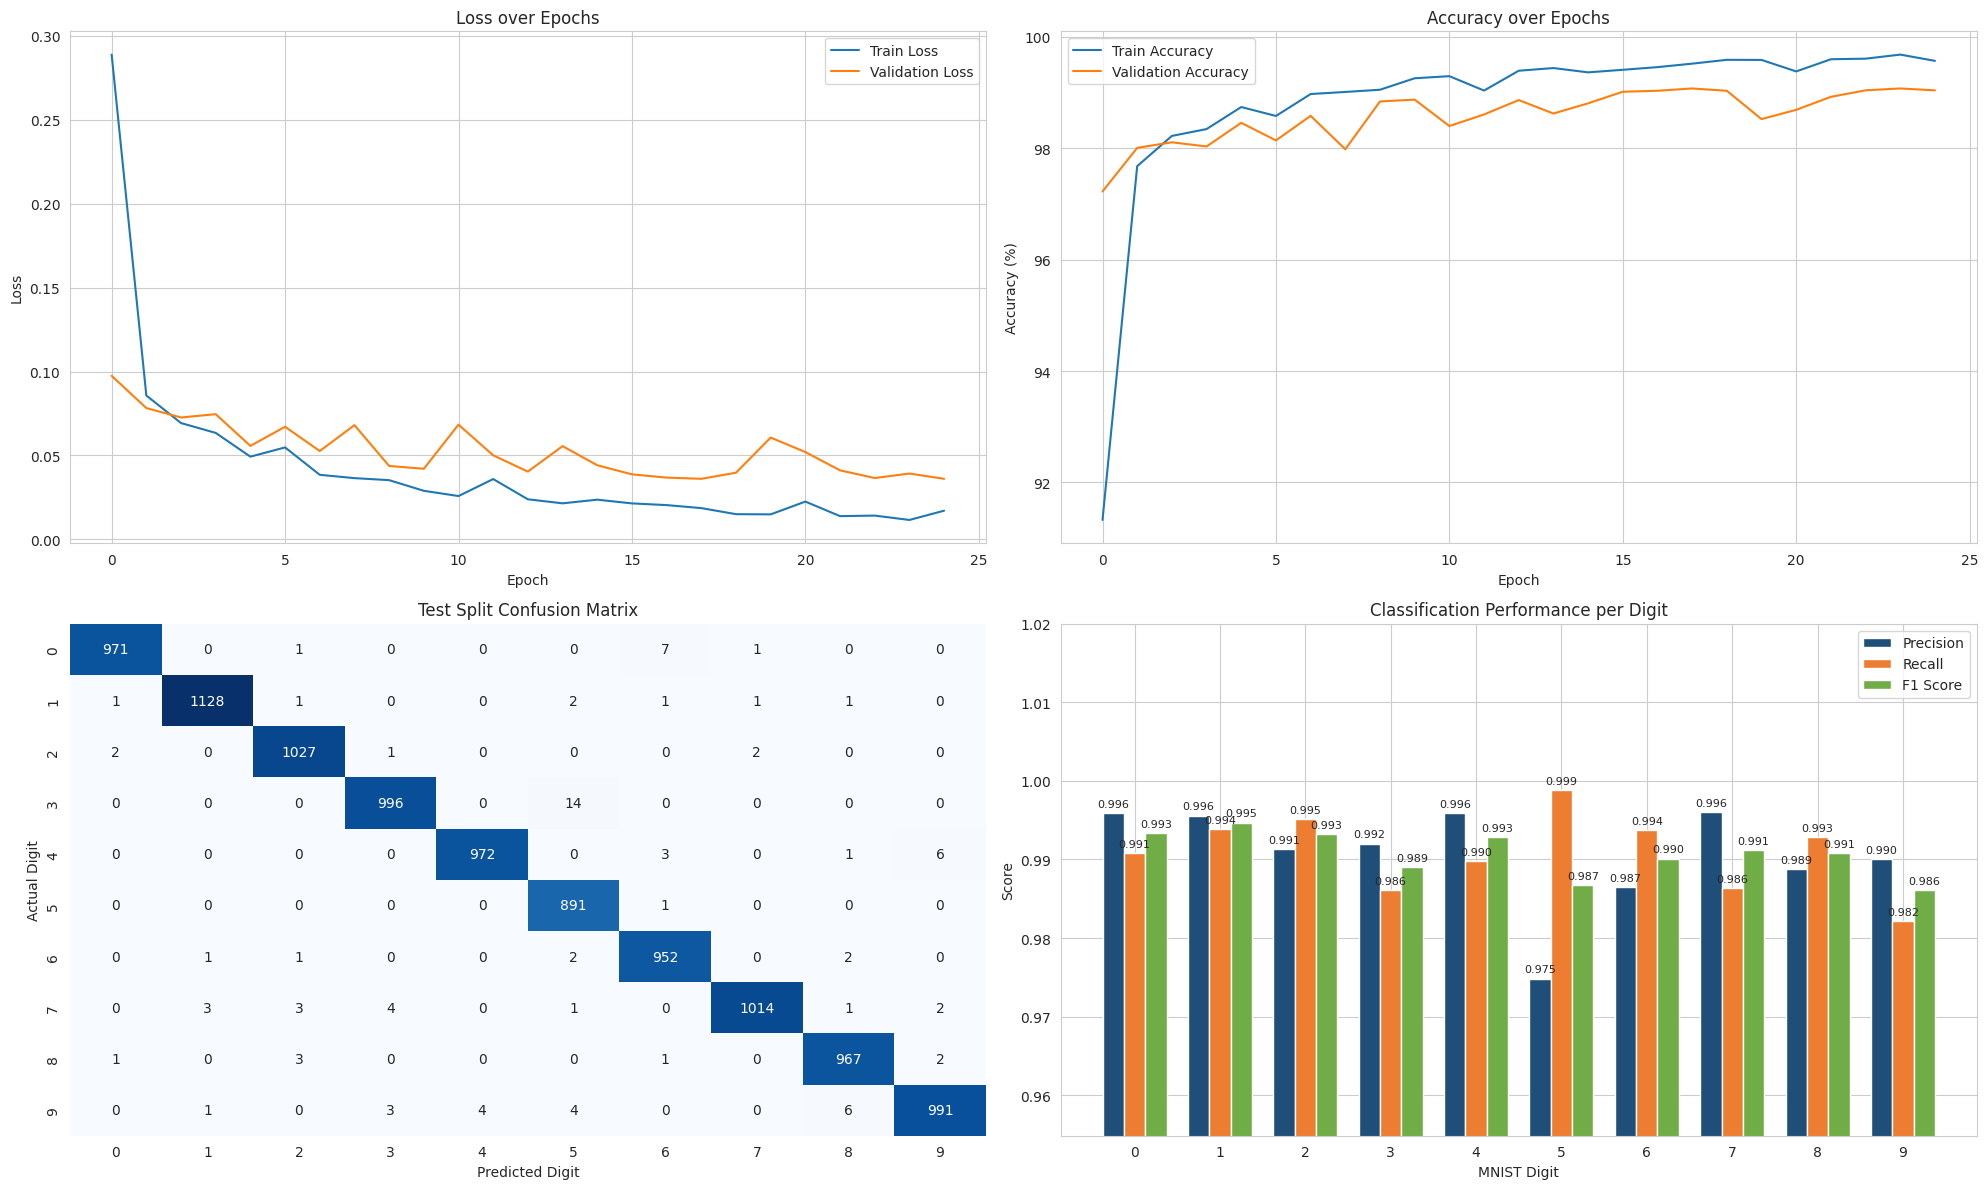

In [ ]:

# --- 3.5 HARDWARE PROFILING (INFERENCE SIMULATION) ---

print("\n" + "="*95)
print("🚀 HARDWARE INFERENCE PROFILING (Batch Size = 1)")
print("Simulating a single hardware prediction cycle to track time and VRAM buffers...")
print("="*95)

# Fetch 1 real image from the test set instead of random noise
data_iterator = iter(test_loader)
real_images, real_labels = next(data_iterator)
single_test_image = real_images[0:1].to(device) # Slice [0:1] keeps Batch Size = 1, Shape: (1, 3, 32, 32)

model.eval()

start_times = {}
layer_profiles = {} # Dictionary to store detailed chronological VRAM profiles

# Define "stopwatches" (Hooks) to attach to our layers
def pre_hook(module, input, layer_name):
    if device.type == 'cuda': torch.cuda.synchronize()
    start_times[layer_name] = {
        'time': time.perf_counter(),
        'mem': torch.cuda.memory_allocated(device) if device.type == 'cuda' else 0
    }

def post_hook(module, input, output, layer_name):
    if device.type == 'cuda': torch.cuda.synchronize()
    end_time = time.perf_counter()
    mem_after = torch.cuda.memory_allocated(device) if device.type == 'cuda' else 0

    prof_data = start_times.get(layer_name, {'time': end_time, 'mem': mem_after})
    exec_time = (end_time - prof_data['time']) * 1000.0  # Convert to ms

    # Store metrics for the Detailed Sequential breakdown table
    layer_profiles[layer_name] = {
        'class_name': module.__class__.__name__,
        'start_time': prof_data['time'],
        'duration_ms': exec_time,
        'mem_before_mb': prof_data['mem'] / (1024 ** 2),
        'mem_after_mb': mem_after / (1024 ** 2),
        'mem_delta_mb': (mem_after - prof_data['mem']) / (1024 ** 2)
    }

handles = []
# Attach the stopwatches ONLY to our main C-Blueprint structural blocks
for name, module in model.named_modules():
    if isinstance(module, (ConvBNAct, SqueezeExcitation, MBConv, nn.Linear, nn.AdaptiveAvgPool2d)):
        handles.append(module.register_forward_pre_hook(partial(pre_hook, layer_name=name)))
        handles.append(module.register_forward_hook(partial(post_hook, layer_name=name)))

# 1. Warmup Pass (Wakes up the GPU/CPU to prevent false slow readings)
with torch.no_grad():
    _ = model(single_test_image)

start_times.clear()
layer_profiles.clear()

# 2. Actual Hardware Profiling Pass
with torch.no_grad():
    total_start = time.perf_counter()
    _ = model(single_test_image)
    if device.type == 'cuda': torch.cuda.synchronize()
    total_end = time.perf_counter()

total_exec_time = (total_end - total_start) * 1000

# Detach the stopwatches so they don't interfere with the Testing phase
for h in handles:
    h.remove()


# --- 4. GATHER PREDICTIONS & TIMING ---

print("Gathering data for final metrics (using Test Set)...")
all_preds, all_labels = [], []
test_loss, test_correct, test_total = 0.0, 0, 0
inference_times = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Track batch inference time
        start_inf = time.perf_counter()
        outputs = model(inputs)
        if device.type == 'cuda': torch.cuda.synchronize()
        end_inf = time.perf_counter()
        inference_times.append((end_inf - start_inf) * 1000) # in ms

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)


# --- 5. OVERALL COMPREHENSIVE PERFORMANCE BREAKDOWN ---
from sklearn.metrics import classification_report

final_test_loss = test_loss / len(test_loader)
final_test_acc = 100 * test_correct / test_total
# Average batch time divided by batch size gives us the mean time per image
mean_inference_time = np.mean(inference_times) / 64

print("\n" + "="*95)
print("                            FINAL TEST PERFORMANCE                                ")
print("="*95)
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%")
print(f"Mean Inference Time per Image: {mean_inference_time:.4f} ms")
print(f"Hardware Profiling Total Cycle (Batch=1): {total_exec_time:.4f} ms")

print("\n" + "="*95)
print("             DETAILED SEQUENTIAL LAYER-BY-LAYER EXECUTION TIMING PROFILE          ")
print("="*95)
print(f"{'Execution Order / Layer Path':<45} | {'Time (ms)':<10} | {'Mem Before':<12} | {'Mem After':<11} | {'Delta VRAM':<10}")
print("-" * 110)

# Sort strictly by forward pass chronological execution order
chronological_profiles = sorted(layer_profiles.items(), key=lambda item: item[1].get('start_time', 0))

for name, metrics_data in chronological_profiles:
    display_name = f"{name} ({metrics_data['class_name']})"
    display_name = (display_name[:42] + '...') if len(display_name) > 45 else display_name
    print(f"-> {display_name:<42} | {metrics_data['duration_ms']:<10.3f} | {metrics_data['mem_before_mb']:<9.3f} MB | {metrics_data['mem_after_mb']:<8.3f} MB | {metrics_data['mem_delta_mb']:+10.3f} MB")

print("\n" + "="*95)
print("                    SKLEARN PERFORMANCE MATRIX REPORT                            ")
print("="*95)
print(classification_report(all_labels, all_preds, digits=4))


# --- 6. PLOT DASHBOARD ---
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, labels=range(10))

# Plotting Results (2x2 Dashboard Layout)
fig = plt.figure(figsize=(20, 12))
sns.set_style("whitegrid")

# Graph A: Learning Curves (Loss) - Top Left
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', color='#1f77b4')
plt.plot(val_losses, label='Validation Loss', color='#ff7f0e')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Graph B: Learning Curves (Accuracy) - Top Right
plt.subplot(2, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='#1f77b4')
plt.plot(val_accuracies, label='Validation Accuracy', color='#ff7f0e')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Graph C: Confusion Matrix - Bottom Left
plt.subplot(2, 2, 3)
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.title('Test Split Confusion Matrix')

# Graph D: Classification Performance per Digit (Bar Chart) - Bottom Right
ax = plt.subplot(2, 2, 4)
x = np.arange(10)  # Labels for 0-9 digits
width = 0.25       # Width of the bars

rects1 = ax.bar(x - width, precision, width, label='Precision', color='#1f4e79')
rects2 = ax.bar(x, recall, width, label='Recall', color='#ed7d31')
rects3 = ax.bar(x + width, f1, width, label='F1 Score', color='#70ad47')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_ylabel('Score')
ax.set_xlabel('MNIST Digit')
ax.set_title('Classification Performance per Digit')
ax.set_xticks(x)
ax.set_xticklabels(np.arange(10))

min_val = min(np.min(precision), np.min(recall), np.min(f1))
ax.set_ylim([max(0.0, min_val - 0.02), 1.02])
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
def export_weights_to_c(model, filename="weights.h"):
    print(f"\n" + "="*95)
    print(f"💾 EXPORTING WEIGHTS TO C HEADER: {filename}")
    print("="*95)

    # Ensure model is in eval mode
    model.eval()

    with open(filename, "w") as f:
        f.write("// Auto-generated weights for Custom EfficientNet-B0\n")
        f.write("#ifndef WEIGHTS_H\n#define WEIGHTS_H\n\n")

        state_dict = model.state_dict()
        for name, tensor in state_dict.items():
            clean_name = name.replace('.', '_')
            flat_tensor = tensor.flatten().cpu().numpy()

            f.write(f"// Original PyTorch shape: {list(tensor.shape)}\n")
            f.write(f"const float {clean_name}[{len(flat_tensor)}] = {{\n    ")

            for i, val in enumerate(flat_tensor):
                f.write(f"{val:.6f}f")
                if i < len(flat_tensor) - 1:
                    f.write(", ")
                if (i + 1) % 8 == 0:
                    f.write("\n    ")
            f.write("\n};\n\n")

        f.write("#endif // WEIGHTS_H\n")
    print(f"✅ Success! File {filename} created in Colab storage.")

# Make sure your trained model variable is named 'model'
export_weights_to_c(model, "weights.h")


💾 EXPORTING WEIGHTS TO C HEADER: weights.h
✅ Success! File weights.h created in Colab storage.


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np

def export_mnist_to_bin(filename="mnist_test_data.bin"):
    print("==================================================================")
    print(" 📥 DOWNLOADING & FORMATTING MNIST DATA FOR C ENGINE")
    print("==================================================================")

    # 1. Your exact PyTorch data pipeline (Normalization Included!)
    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # 2. Load the full test set
    test_set = torchvision.datasets.MNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )

    NUM_IMAGES = len(test_set)
    print(f"Loaded {NUM_IMAGES} images.")
    print(f"Writing binary stream to '{filename}'...")

    # 3. Write directly to the binary file
    with open(filename, "wb") as f:
        for i in range(NUM_IMAGES):
            img_tensor, label = test_set[i]

            # Format Label: 32-bit Integer
            label_np = np.array([label], dtype=np.int32)

            # Format Image: Flatten the [3, 32, 32] tensor into a 1D array of 3072 Float32s
            img_np = img_tensor.numpy().astype(np.float32).flatten()

            # Write to file (ORDER IS CRITICAL: Label first, then Image)
            label_np.tofile(f)
            img_np.tofile(f)

            if (i + 1) % 2000 == 0:
                print(f"   -> Processed {i + 1} / {NUM_IMAGES} images...")

    print("==================================================================")
    print(f" ✅ EXPORT COMPLETE! File saved as: {filename}")
    print("==================================================================")

if __name__ == "__main__":
    export_mnist_to_bin()

 📥 DOWNLOADING & FORMATTING MNIST DATA FOR C ENGINE
Loaded 10000 images.
Writing binary stream to 'mnist_test_data.bin'...
   -> Processed 2000 / 10000 images...
   -> Processed 4000 / 10000 images...
   -> Processed 6000 / 10000 images...
   -> Processed 8000 / 10000 images...
   -> Processed 10000 / 10000 images...
 ✅ EXPORT COMPLETE! File saved as: mnist_test_data.bin


In [ ]:
import torch
import numpy as np

# Assuming you already have 'pytorch_preds' as a list of 10,000 integers
# pytorch_preds = [7, 2, 1, 0, 4, ...]

# Convert to a 32-bit integer numpy array
preds_array = np.array(all_preds, dtype=np.int32)

# Save directly to a binary file
preds_array.tofile("pytorch_preds.bin")
print("Exported 10,000 PyTorch predictions to pytorch_preds.bin")

In [ ]:
import numpy as np
import struct
import torch
import torch.ao.quantization as quant
import torch.nn as nn

print("\n==================================================================")
print(" ⚙️ INITIATING POST-TRAINING STATIC QUANTIZATION (INT8)")
print("==================================================================")

# Ensure the model is in eval mode and on the CPU
model.eval()
model.to('cpu')

# 1. The TRUE Auto-Fusion Loop
modules_fused = 0
for name, module in model.named_modules():
    # Fuse Stem and Depthwise layers
    if type(module).__name__ == 'ConvBNAct':
        quant.fuse_modules(module, ['conv', 'bn'], inplace=True)
        modules_fused += 1

    # Fuse the Pointwise Conv+BN inside MBConv
    elif type(module).__name__ == 'MBConv':
        conv_name, bn_name = None, None
        for sub_name, sub_module in module.block.named_children():
            if isinstance(sub_module, nn.Conv2d):
                conv_name = sub_name
            elif isinstance(sub_module, nn.BatchNorm2d):
                bn_name = sub_name
        if conv_name and bn_name:
            quant.fuse_modules(module.block, [conv_name, bn_name], inplace=True)
            modules_fused += 1

print(f"✅ Successfully fused {modules_fused} Conv+BatchNorm layer pairs. (Should be 49!)")

# 2. Attach a PER-TENSOR QConfiguration
per_tensor_qconfig = quant.QConfig(
    activation=quant.HistogramObserver.with_args(reduce_range=False),
    weight=quant.MinMaxObserver.with_args(dtype=torch.qint8, qscheme=torch.per_tensor_symmetric)
)
model.qconfig = per_tensor_qconfig
quant.prepare(model, inplace=True)

# 3. Calibration Pass
print("⏳ Calibrating model using 512 images to determine exact scales...")
calibration_batches = 0
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to('cpu')
        model(inputs)
        calibration_batches += 1
        if calibration_batches >= 8:
            break

# 4. Final INT8 Conversion
quant.convert(model, inplace=True)
print("✅ Calibration complete. Model converted to INT8 format.")

# ---------------------------------------------------------
# 5. EXPORT THE WEIGHTS TO C-READABLE BINARY
# ---------------------------------------------------------
print("📦 Exporting weights, dynamic boundaries, and ALL folded biases...")

exported_layers = 0
with open("quantized_weights.bin", "wb") as f:
    for name, module in model.named_modules():

        # Skip stray unfused layers to prevent stream corruption
        if any(skip_type in str(type(module)) for skip_type in ['BatchNorm', 'Pool', 'Sequential', 'CustomEfficientNetB0', 'MBConv', 'ConvBNAct', 'SqueezeExcitation']):
            continue

        if hasattr(module, 'weight') and module.weight is not None:
            exported_layers += 1
            weight_tensor = module.weight() if callable(module.weight) else module.weight

            if weight_tensor.is_quantized:
                int8_weights = weight_tensor.int_repr().numpy().astype(np.int8)

                if weight_tensor.qscheme() in [torch.per_channel_affine, torch.per_channel_symmetric]:
                    f.write(struct.pack('f', float(weight_tensor.q_per_channel_scales().numpy()[0])))
                    f.write(struct.pack('i', int(weight_tensor.q_per_channel_zero_points().numpy()[0])))
                else:
                    f.write(struct.pack('f', float(weight_tensor.q_scale())))
                    f.write(struct.pack('i', int(weight_tensor.q_zero_point())))
                f.write(int8_weights.tobytes())

                if hasattr(module, 'scale'):
                    f.write(struct.pack('f', float(module.scale)))
                    f.write(struct.pack('i', int(module.zero_point)))
                else:
                    f.write(struct.pack('f', 1.0))
                    f.write(struct.pack('i', 0))

            else:
                w_np = weight_tensor.detach().numpy()
                w_max = np.max(np.abs(w_np)) + 1e-9
                scale = w_max / 127.0
                int8_weights = np.clip(np.round(w_np / scale), -127, 127).astype(np.int8)

                f.write(struct.pack('f', float(scale)))
                f.write(struct.pack('i', 0))
                f.write(int8_weights.tobytes())

                f.write(struct.pack('f', 1.0))
                f.write(struct.pack('i', 0))

            # Universal Bias Write
            out_c = weight_tensor.shape[0]
            f.write(struct.pack('i', out_c))

            if hasattr(module, 'bias') and module.bias is not None:
                bias_tensor = module.bias() if callable(module.bias) else module.bias
                if bias_tensor is not None:
                    float_bias = bias_tensor.detach().numpy().astype(np.float32)
                else:
                    float_bias = np.zeros(out_c, dtype=np.float32)
            else:
                float_bias = np.zeros(out_c, dtype=np.float32)

            f.write(float_bias.tobytes())

print(f"🚀 Successfully exported {exported_layers} neural blocks.")
print("==================================================================")


 ⚙️ INITIATING POST-TRAINING STATIC QUANTIZATION (INT8)
✅ Successfully fused 49 Conv+BatchNorm layer pairs. (Should be 49!)
⏳ Calibrating model using 512 images to determine exact scales...


/tmp/ipykernel_501/310593845.py:43: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quant.prepare(model, inplace=True)
/tmp/ipykernel_501/310593845.py:57: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please 

✅ Calibration complete. Model converted to INT8 format.
📦 Exporting weights, dynamic boundaries, and ALL folded biases...
🚀 Successfully exported 82 neural blocks.


In [ ]:
import torch

captured_params = []

# 1. The Ninja Hook: Catch the data and pull the fire alarm
def ninja_hook(module, inputs):
    inp = inputs[0]
    if hasattr(inp, 'q_scale'):
        captured_params.append((float(inp.q_scale()), int(inp.q_zero_point())))
    else:
        captured_params.append((0.0078, 0)) # Fallback if no QuantStub was used

    # Abort the forward pass instantly so PyTorch's broken SiLU never runs!
    raise RuntimeError("ABORT_BEFORE_SILU")

# 2. Attach hook to the very first Conv2d layer
for name, module in model.named_modules():
    if 'Conv2d' in str(type(module)):
        handle = module.register_forward_pre_hook(ninja_hook)
        break

# 3. Feed a dummy image to trigger the trap
dummy_img = torch.randn(1, 3, 32, 32)
try:
    model(dummy_img)
except RuntimeError as e:
    if str(e) == "ABORT_BEFORE_SILU":
        pass # Perfect, we stopped it just in time!
    else:
        raise e
finally:
    handle.remove()

# 4. Print the stolen parameters
print("\n🚨 C-ENGINE ENTRY CALIBRATION 🚨")
print(f"Input Scale: {captured_params[0][0]}f")
print(f"Input ZP: {captured_params[0][1]}")